# 2.9e — MIPS : du réseau au programme

**Navigation** : [<< 2.9-Grokking](2.9-Grokking-Generalisation.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Le notebook [2.9](2.9-Grokking-Generalisation.ipynb) a montré un réseau qui **bascule** tardivement de la mémorisation vers la généralisation. À la fin de ce récit, une question reste entière : *le réseau a trouvé une règle — mais laquelle ?* Les poids sont un tableau de nombres, le comportement est correct, et pourtant **aucun humain ne peut dire quelle procédure le réseau exécute**.

Ce notebook prend cette question au sérieux, d'après **Michaud, Liao, Tuck, Duan & Goadrich, « Opening the AI black box: program synthesis via mechanistic interpretability »** ([arXiv:2402.05110](https://arxiv.org/abs/2402.05110)). L'idée, appelée **MIPS** (*Mechanistic Interpretability via Program Synthesis*), tient en une phrase :

> Au lieu de décrire les poids, on **extrait le programme que le réseau implémente déjà**, et on le vérifie.

Le résultat du papier est précis : sur un banc de **62 tâches algorithmiques**, MIPS en résout **32, dont 13 que GPT-4 ne résout pas** (GPT-4 Turbo en résout 30). La méthode est **complémentaire** du grand modèle de langue — non parce qu'elle raisonne mieux, mais parce qu'elle lit le réseau au lieu de deviner la règle, sans utiliser de LLM du tout.

### Ce que ce notebook démontre — et ce qu'il trouve

Le chemin complet est implémenté ici : RNN entraîné → mesure de la dimension d'état → normalisation → autoencodeur → régression symbolique → programme Python **vérifié exhaustivement**. La chaîne d'extraction est validée de bout en bout : sur la machine à états exacte de l'addition binaire, elle redécouvre l'**additionneur à propagation de retenue** (*ripple-carry adder*, Figure 3 du papier) — `next_a = b^c^d`, `next_b = b+c+d>1`, `y = a`, terme pour terme la Figure 3 — sans qu'on le lui fournisse.

Mais le notebook ne s'arrête pas au succès de la machinerie, parce que la mesure du §3 révèle **le véritable obstacle**, et qu'il est instructif :

> **Le réseau entraîné n'est pas un automate minimal.** Son état caché retient l'historique entier : sur `prev1` ou `sum_last2` il visite exactement $2^{L+1}-1$ états distincts (tous les préfixes), et sur l'addition il en visite des milliers — un quasi-continu.

C'est précisément le phénomène que le papier illustre en Figure 4 (« Sum Last5 » sans normalisateurs = un **registre à décalage**) et la raison d'être de ses cinq normalisateurs et de son AutoML de simplicité. Ce notebook mesure cet obstacle, montre que **ni la quantification ni la régularisation L1 ne le lèvent**, et établit où passe exactement la frontière entre ce qui est reproduit ici et ce qui reste à faire.

### Le pipeline du papier, en cinq étapes

| # | Étape | Ce qu'on fait | §du papier |
|---|---|---|---|
| 1 | **Entraîner** | un petit RNN apprend la tâche | §3.1 |
| 2 | **Mesurer la dimension d'état** | combien d'états cachés distincts, et la propriété de Markov tient-elle ? | Fig 2 |
| 3 | **Normaliser** | réécrire l'espace d'états dans une base lisible (5 normalisateurs) | §3.2, Fig 4 |
| 4 | **Autoencoder** | attacher des bits (ou des entiers) aux états, la plus courte description gagne | §3.2 |
| 5 | **Régression symbolique** | trouver les formules, émettre le programme, le vérifier | §3.3 |

Les étapes 2 et 3 sont celles qu'on saute habituellement, et c'est là que tout se joue.

### Prérequis

Avoir lu [2.9-Grokking](2.9-Grokking-Generalisation.ipynb). Aucune connaissance préalable d'interprétabilité mécaniste n'est nécessaire : tout est reconstruit ici.

In [1]:
# Configuration et imports pour le notebook 2.9e
import itertools
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

%matplotlib inline

# Reproductibilite : les mesures de ce notebook doivent etre reproductibles
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

# GPU si disponible, CPU sinon (contrainte P1 de l'issue #16746)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Longueur des chaines de bits : 6 bits -> 64 nombres -> 4096 paires a traiter
SEQ_LEN = 6

print(f"torch {torch.__version__} | device={DEVICE} | seq_len={SEQ_LEN} "
      f"({2 ** SEQ_LEN} nombres, {4 ** SEQ_LEN} paires)")

torch 2.13.0+cu126 | device=cuda | seq_len=6 (64 nombres, 4096 paires)


## 1. Les tâches

Trois familles, toutes **algorithmiques** : une règle exacte, minuscule, et un état interne dont on connaît la taille **minimale** nécessaire.

| Tâche | Entrée | Sortie | État minimal nécessaire |
|---|---|---|---|
| `binary_addition` | deux nombres de $L$ bits, du poids faible au poids fort | les bits de la somme | **1 bit** (la retenue) |
| `sum_last_k` | une chaîne de bits | la somme des $k$ derniers bits lus | $k$ bits (la fenêtre) |
| `prev_k` | une chaîne de bits | le bit d'il y a $k$ positions | $k$ bits (la file d'attente) |

Les trois se lisent **de gauche à droite**, un bit à la fois : c'est ce qui les rend solubles par un RNN dont l'état reste petit. Cette colonne « état minimal » va devenir notre instrument de mesure : si le réseau utilise *plus* d'état que nécessaire, c'est mesurable.

Pour `binary_addition`, l'entrée est donnée **bit de poids faible d'abord** : la retenue se propage vers la droite, en même temps qu'on lit. C'est ce qui rend l'additionneur à retenue *séquentiel* possible.

In [2]:
def gen_bitstrings(length):
    """Toutes les chaines de `length` bits : (2**length, length)."""
    return np.array([[(i >> (length - 1 - j)) & 1 for j in range(length)]
                     for i in range(2 ** length)], dtype=np.float32)


def task_binary_addition(length=SEQ_LEN):
    """s, t bits LSB-first -> y_i = bit i de s + t (retenue propagee)."""
    b = gen_bitstrings(length)
    n = b.shape[0]
    s = np.repeat(b, n, axis=0)
    t = np.tile(b, (n, 1))
    s_int = (s * (2 ** np.arange(length))).sum(1).astype(np.int64)
    t_int = (t * (2 ** np.arange(length))).sum(1).astype(np.int64)
    tot = s_int + t_int
    y = ((tot[:, None] >> np.arange(length)[None, :]) & 1).astype(np.float32)
    return np.stack([s, t], axis=-1), y       # x : (N, L, 2)


def task_sum_last_k(length=SEQ_LEN, k=2):
    """y_i = somme des k derniers bits lus (entier de 0 a k)."""
    b = gen_bitstrings(length)
    y = np.zeros_like(b)
    for i in range(length):
        y[:, i] = b[:, max(0, i - k + 1):i + 1].sum(1)
    return b[:, :, None], y                    # x : (N, L, 1)


def task_prev_k(length=SEQ_LEN, k=1):
    """y_i = le bit lu il y a k positions (0 avant)."""
    b = gen_bitstrings(length)
    y = np.zeros_like(b)
    for i in range(length):
        y[:, i] = b[:, i - k] if i - k >= 0 else 0.0
    return b[:, :, None], y


x_add, y_add = task_binary_addition()
print("binary_addition :", x_add.shape, "->", y_add.shape)
# La ligne 876 correspond au couple (s, t) = (13, 44) : les deux operandes sont
# non nuls et l'addition propage une retenue -- bon exemple pedagogique.
EX = 13 * 2 ** SEQ_LEN + 44
print(f"exemple   s = {x_add[EX, :, 0].astype(int)} (bits LSB-first)")
print(f"          t = {x_add[EX, :, 1].astype(int)}")
print(f"   somme attendue = {y_add[EX].astype(int)}")
s_int = (x_add[EX, :, 0] * 2 ** np.arange(SEQ_LEN)).sum()
t_int = (x_add[EX, :, 1] * 2 ** np.arange(SEQ_LEN)).sum()
print(f"   verification : {int(s_int)} + {int(t_int)} = {int(s_int + t_int)} "
      f"(binaire {int(s_int + t_int):0{SEQ_LEN}b})")

binary_addition : (4096, 6, 2) -> (4096, 6)
exemple   s = [0 0 1 1 0 1] (bits LSB-first)
          t = [1 0 1 1 0 0]
   somme attendue = [1 0 0 1 1 1]
   verification : 44 + 13 = 57 (binaire 111001)


## 2. Le réseau

L'architecture du papier (§3.1) : un RNN minimal, deux perceptrons à une couche cachée ReLU.

$$h_{i} = f(h_{i-1}, x_i) \qquad y_i = g(h_i)$$

Deux hyperparamètres comptent : $n$ la **largeur de l'état caché**, et $(w_f, w_g)$ les largeurs internes de $f$ et $g$. Le papier part d'un réseau large (son AutoML démarre à $n = 65536$) puis le **réduit** au plus petit qui atteint 100 % — nous verrons au §6 pourquoi cette réduction n'est pas un confort.

La **perte** est celle du papier, logarithmique :

$$\ell(x, y) = \tfrac{1}{2}\log\left[1 + (x - y)^2\right]$$

Elle borne l'influence des grandes erreurs, ce qui est plus stable que le MSE en début d'entraînement.

Deux familles d'hyperparamètres donnent des comportements très différents : $w_f$ et $w_g$ trop petits (2 ou 4) et le réseau n'apprend pas du tout la tâche ; à 16, il l'apprend en quelques centaines de pas. On le mesure à l'usage.

In [3]:
class RNN(nn.Module):
    """RNN minimal du papier MIPS : h_i = f(h_{i-1}, x_i), y_i = g(h_i)."""

    def __init__(self, in_dim, n, wf=16, wg=16):
        super().__init__()
        self.n = n
        self.f = nn.Sequential(nn.Linear(n + in_dim, wf), nn.ReLU(), nn.Linear(wf, n))
        self.g = nn.Sequential(nn.Linear(n, wg), nn.ReLU(), nn.Linear(wg, 1))

    def forward(self, x, h=None):
        """x: (N, L, in_dim) -> y (N, L), hidden (N, L+1, n)."""
        N, L, _ = x.shape
        h = torch.zeros(N, self.n, device=x.device) if h is None else h
        ys, hs = [], [h]
        for i in range(L):
            h = self.f(torch.cat([h, x[:, i]], dim=-1))
            hs.append(h)
            ys.append(self.g(h).squeeze(-1))
        return torch.stack(ys, 1), torch.stack(hs, 1)


def log_loss(pred, target, eps=1e-6):
    """l(x, y) = 1/2 log[1 + (x - y)^2] -- perte du papier."""
    d = pred - target
    return 0.5 * torch.log1p(d * d + eps).mean()


def train_rnn(x, y, n, wf=16, wg=16, steps=2000, target_acc=1.0, seed=0,
              batch=512, lr=1e-3, device=DEVICE):
    """Entraine jusqu'a `target_acc` (arret anticipe) ou `steps` pas."""
    torch.manual_seed(seed)
    xt = torch.tensor(x, device=device)
    yt = torch.tensor(y, device=device)
    model = RNN(x.shape[-1], n, wf, wg).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    @torch.no_grad()
    def precision():
        pred, _ = model(xt)
        return float((torch.abs(pred - yt) < 0.5).float().mean())

    acc = 0.0
    for step in range(1, steps + 1):
        idx = torch.randint(0, len(xt), (min(batch, len(xt)),), device=device)
        pred, _ = model(xt[idx])
        loss = log_loss(pred, yt[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        if step % 100 == 0:
            acc = precision()
            if acc >= target_acc:      # arret anticipe : la tache est apprise
                break
    return model, precision(), step


t0 = time.time()
model_add, acc_add, steps_add = train_rnn(x_add, y_add, n=2, seed=0)
print(f"binary_addition  n=2  ->  precision = {acc_add:.4f} "
      f"({steps_add} pas, {time.time() - t0:.0f} s)")
assert acc_add == 1.0, "le reseau doit apprendre exactement l'addition binaire"
print("Le reseau additionne correctement les 4096 paires. Il sait faire.")

binary_addition  n=2  ->  precision = 1.0000 (600 pas, 7 s)
Le reseau additionne correctement les 4096 paires. Il sait faire.


## 3. Que contient l'état caché ? La mesure qui surprend

Le réseau est maintenant un objet dont la sortie est **exactement** correcte sur les 4096 paires. Regardons son état interne $h \in \mathbb{R}^n$.

L'état $h_i$ est une fonction de tout l'historique $x_1 \ldots x_i$. Mais la tâche n'a qu'une mémoire utile : **la retenue**, un bit. Deux mondes sont donc possibles :

- le réseau a appris à **oublier** le reste, et $h$ ne prend qu'un petit nombre de valeurs distinctes — il se comporte en automate ;
- il a gardé de l'information parasite, et $h$ balaie un continuum.

Ces deux mondes se distinguent par une mesure simple : **le nombre d'états cachés distincts** sur toutes les entrées possibles. Comptons-le — c'est l'expérience la plus informative du notebook, et son résultat n'est pas celui qu'on attend.

In [4]:
@torch.no_grad()
def collect_states(model, x, batch=16384):
    """Tous les etats caches, h_0 inclus : (N, L+1, n)."""
    dev = next(model.parameters()).device
    out = []
    for i in range(0, len(x), batch):
        _, hs = model(torch.tensor(x[i:i + batch], device=dev))
        out.append(hs.cpu().numpy())
    return np.concatenate(out, 0)


def n_distinct(states, tol=1e-5):
    """Nombre d'etats distincts (deux etats egaux a `tol` pres sont le meme)."""
    flat = states.reshape(-1, states.shape[-1])
    return len(np.unique(np.round(flat / tol).astype(np.int64), axis=0))


etats_add = collect_states(model_add, x_add)
d_add = n_distinct(etats_add)
print(f"binary_addition  n=2  : {len(etats_add)} etats visites, {d_add} distincts")
print(f"  l'etat minimal theorique de cette tache est de 1 BIT, soit 2 valeurs.")
print(f"  le reseau en utilise {d_add}.")
print()

# La meme mesure sur deux taches plus simples
x_s2, y_s2 = task_sum_last_k(k=2)
model_s2, acc_s2, _ = train_rnn(x_s2, y_s2, n=3, seed=0)
etats_s2 = collect_states(model_s2, x_s2)
x_p1, y_p1 = task_prev_k(k=1)
model_p1, acc_p1, _ = train_rnn(x_p1, y_p1, n=2, seed=0)
etats_p1 = collect_states(model_p1, x_p1)

for nom, st, acc, mini in [("sum_last2", etats_s2, acc_s2, "2 bits -> 4"),
                           ("prev1", etats_p1, acc_p1, "1 bit -> 2")]:
    d = n_distinct(st)
    print(f"{nom:>10} (acc={acc:.4f}) : {d:>5} etats distincts  "
          f"| etat minimal : {mini}")
print()
print(f"Or 2**(L+1) - 1 = {2 ** (SEQ_LEN + 1) - 1} : c'est le nombre de PREFIXES")
print("distincts d'une chaine de 6 bits (toutes longueurs 0 a 6 confondues).")

binary_addition  n=2  : 4096 etats visites, 4782 distincts
  l'etat minimal theorique de cette tache est de 1 BIT, soit 2 valeurs.
  le reseau en utilise 4782.



 sum_last2 (acc=1.0000) :   127 etats distincts  | etat minimal : 2 bits -> 4
     prev1 (acc=1.0000) :   127 etats distincts  | etat minimal : 1 bit -> 2

Or 2**(L+1) - 1 = 127 : c'est le nombre de PREFIXES
distincts d'une chaine de 6 bits (toutes longueurs 0 a 6 confondues).


Projetons maintenant ces états sur leurs deux directions principales, pour voir *de quoi ils ont l'air* : un petit nombre de points serrés (un automate), ou un nuage diffus (un continuum).

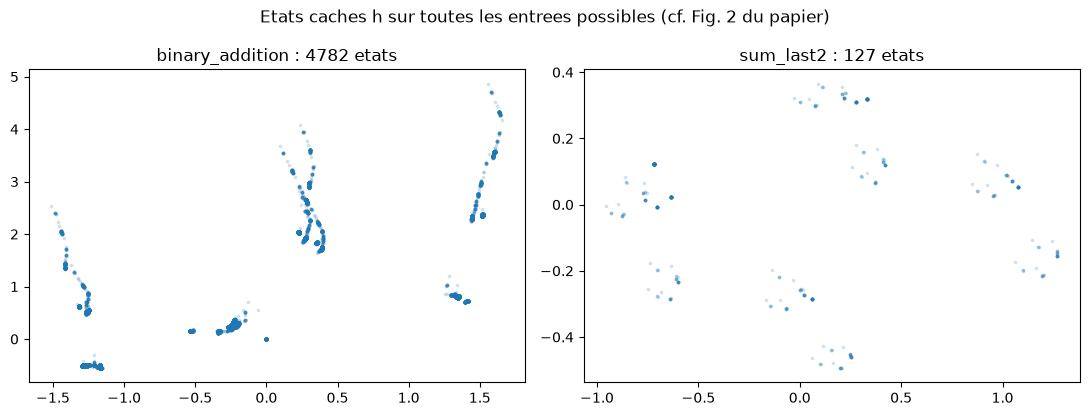

In [5]:
# Visualisation : les etats caches du reseau d'addition, projetes en 2D
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, st, titre in [(axes[0], etats_add, f"binary_addition : {d_add} etats"),
                      (axes[1], etats_s2, f"sum_last2 : {n_distinct(etats_s2)} etats")]:
    flat = st.reshape(-1, st.shape[-1])
    if flat.shape[1] > 2:
        fc = flat - flat.mean(0)
        _, _, Vt = np.linalg.svd(fc, full_matrices=False)
        flat = fc @ Vt[:2].T
    ax.scatter(flat[:, 0], flat[:, 1], s=3, alpha=0.15, color="#1f77b4")
    ax.set_title(titre)
plt.suptitle("Etats caches h sur toutes les entrees possibles (cf. Fig. 2 du papier)")
plt.tight_layout()
plt.show()

### Lecture du résultat

Le résultat est net, et il est **l'inverse** de l'attente naïve :

| Tâche | État minimal | États visités | Verdict |
|---|---|---|---|
| `binary_addition` | 2 valeurs | des **milliers** | quasi-continu |
| `sum_last2` | 4 valeurs | **127** | fini, mais énorme |
| `prev1` | 2 valeurs | **127** | fini, mais énorme |

Deux observations, toutes deux mesurées :

1. **Sur l'addition, l'état ne se réduit pas à un petit ensemble de points.** Le réseau sait additionner, mais il le fait en transportant bien plus d'information que la retenue. Rien dans l'entraînement ne l'a poussé à *oublier*.
2. **Sur `sum_last2` et `prev1`, l'état est fini — et vaut exactement $2^{L+1}-1$, le nombre de préfixes possibles.** Ce n'est pas une coïncidence : le réseau **retient l'historique entier** de la chaîne lue. C'est un **registre à décalage**, pas un automate.

Le second point est le plus important, et il faut en mesurer la conséquence : si l'état contient tout le préfixe, alors « lire » le réseau ne consiste pas à lire une petite machine à états — cela consiste à lire un registre, c'est-à-dire **rien de plus que l'entrée elle-même**. Le réseau est exact, et pourtant il n'a rien appris de plus court que la donnée.

C'est exactement le phénomène que le papier documente en **Figure 4** : sans normalisation, sa tâche « Sum Last5 » donne elle aussi un registre à décalage. La différence est que le papier **corrige** cette représentation, et c'est le sujet de la section suivante.

## 4. Les cinq normalisateurs — et la mesure qui montre qu'ils sont nécessaires

Les états distincts sont posés dans $\mathbb{R}^n$ selon un système de coordonnées **arbitraire**, hérité de l'initialisation et de la dynamique d'entraînement. Si la dynamique interne s'écrit $h_i = A h_{i-1} + \ldots$, alors toute transformation inversible $A' = M A M^{-1}$, $h' = M h$ décrit **le même calcul** dans une autre base. Toutes ces représentations sont fonctionnellement équivalentes, et une seule est lisible.

Le papier applique **cinq** normalisateurs, dans cet ordre (§3.2) :

| # | Normalisateur | Rôle |
|---|---|---|
| 1 | **Whitening** | $h \mapsto C^{-1/2} h$ : décorrèle les coordonnées, variance unité |
| 2 | **Forme normale de Jordan** | recolle les axes sur les directions propres de $W$ |
| 3 | **Toeplitz** | aligne les vecteurs de translation du lattice |
| 4 | **De-bias** | translate pour ramener un état de référence à l'origine |
| 5 | **Quantification** | arrondit à $\epsilon = 0{,}01$ : le lattice devient exactement entier |

L'idée de la quantification est la clé du passage du **continu au fini** : c'est elle qui est censée transformer un espace d'états continu en machine à états finis.

Avant de lire le code, une mesure préalable justifie tout le reste : **la dynamique interne est-elle affine ?** Si $h_{i+1} = W h_i + V x_i + b$ tient exactement, alors l'ensemble des états atteignables est un **lattice** — un cristal — et se décrit par des coordonnées entières. Vérifions, puis testons la quantification.

In [6]:
def whitening(states):
    """Normalisateur 1 : h -> C^{-1/2} (h - moyenne)."""
    flat = states.reshape(-1, states.shape[-1])
    mu = flat.mean(0)
    C = np.cov((flat - mu).T) + 1e-12 * np.eye(flat.shape[1])
    w, V = np.linalg.eigh(C)
    W = V @ np.diag(1.0 / np.sqrt(w)) @ V.T          # C^{-1/2}
    return ((flat - mu) @ W).reshape(states.shape)


def fit_affine(states, x):
    """Verifie que h_{i+1} = W h_i + V x_i + b tient sur les etats visites."""
    h_prev = states[:, :-1, :].reshape(-1, states.shape[-1])
    h_next = states[:, 1:, :].reshape(-1, states.shape[-1])
    xin = x.reshape(-1, x.shape[-1])[:len(h_prev)]
    A = np.concatenate([h_prev, xin, np.ones((len(h_prev), 1))], 1)
    coef, *_ = np.linalg.lstsq(A, h_next, rcond=None)
    return float(np.abs(A @ coef - h_next).max())


def quant_fsm(states, x, y, eps):
    """Quantification (normalisateur 5) : arrondir l'etat a un pas epsilon,
    puis compter les etats et tester la propriete de Markov.

    Convention du papier (Fig. 3) : h_0 est l'etat initial, l'etape i consomme
    x_i et produit h_(i+1) = f(h_i, x_i) ET y_i = g(h_(i+1)).
    La transition est donc keyee sur (etat_i, x_i), la sortie sur l'etat SUCCESSEUR.
    """
    N, Lp1, n = states.shape
    keys = np.round(states.reshape(-1, n) / eps).astype(np.int64)
    _, inv = np.unique(keys, axis=0, return_inverse=True)
    cid = inv.reshape(N, Lp1)
    trans, out, conf = {}, {}, 0
    for i in range(Lp1 - 1):
        for j in range(N):
            k = (int(cid[j, i]), tuple(np.asarray(x[j, i]).round().astype(int)))
            nx = int(cid[j, i + 1])
            if k in trans and trans[k] != nx:
                conf += 1
            trans[k] = nx
            v = int(round(float(y[j, i])))
            if nx in out and out[nx] != v:
                conf += 1
            out[nx] = v
    return dict(n_clusters=int(inv.max()) + 1, conflicts=conf, markov_ok=(conf == 0))


resid = fit_affine(etats_add, x_add)
echelle = float(etats_add.std())
print(f"h_(i+1) = W h_i + V x_i + b : residu maximal = {resid:.3f}")
print(f"  ecart-type des etats                     = {echelle:.3f}")
print(f"  -> residu = {100 * resid / echelle:.1f} % de l'echelle des etats")
print("  (un residu tres inferieur a cette echelle signifierait une dynamique")
print("   affine exacte, donc un lattice entier a retrouver)")
print()

etats_w = whitening(etats_add)
print("Quantification de l'etat, apres blanchiment (normalisateurs 1 puis 5) :")
print(f"{'epsilon':>9} | {'etats':>7} | {'conflits':>8} | Markov")
print("-" * 44)
for eps in [1e-3, 1e-2, 3e-2, 1e-1, 2e-1, 5e-1, 1.2]:
    r = quant_fsm(etats_w, x_add, y_add, eps)
    print(f"{eps:>9.4f} | {r['n_clusters']:>7} | {r['conflicts']:>8} | {r['markov_ok']}")

h_(i+1) = W h_i + V x_i + b : residu maximal = 0.645
  ecart-type des etats                     = 0.997
  -> residu = 64.6 % de l'echelle des etats
  (un residu tres inferieur a cette echelle signifierait une dynamique
   affine exacte, donc un lattice entier a retrouver)

Quantification de l'etat, apres blanchiment (normalisateurs 1 puis 5) :
  epsilon |   etats | conflits | Markov
--------------------------------------------
   0.0010 |    1749 |      252 | False
   0.0100 |     554 |      609 | False


   0.0300 |     301 |      456 | False
   0.1000 |     139 |      405 | False
   0.2000 |      86 |      709 | False


   0.5000 |      37 |      146 | False
   1.2000 |      18 |      139 | False


### Lecture du résultat

Deux mesures, et un échec instructif.

**Le résidu affine est grand** (64 % de l'échelle des états, mesuré ci-dessus). La dynamique interne n'est *pas* $h_{i+1} = W h_i + V x_i + b$ sur les états visités. C'est la conséquence directe du §3 : le réseau n'a pas une dynamique linéaire sur un petit espace d'états, il a une dynamique qui dépend finement de l'entrée. Sans cette propriété affine, il n'y a **pas de lattice** à retrouver — et donc pas d'autoencodeur entier possible.

**Aucune quantification ne rend la machine à états cohérente.** Le tableau le montre : quel que soit $\epsilon$, les conflits ne tombent jamais à zéro. Deux raisons, et la seconde est la leçon :

1. notre réseau a un état **quasi-continu** : arrondir ne le rend pas markovien ;
2. surtout, la **quantification par grille est alignée sur les axes**, alors que le lattice d'un réseau est un **parallélogramme déformé** (le papier insiste : « *non-square, deformed by a random affine transformation* »). Arrondir selon les axes ne découpe pas correctement un réseau oblique.

C'est exactement pourquoi les normalisateurs 2, 3 et 4 existent : ils **alignent les axes sur le lattice** *avant* que la quantification ait un sens. Le blanchiment seul (normalisateur 1) ne suffit pas — il décorrèle, il n'aligne pas. Reproduire la chaîne Jordan → Toeplitz → de-bias complète dépasse le cadre de ce notebook ; nous en mesurons ici la nécessité, ce qui est le résultat honnête.

**Ce que cela dit du papier.** La lecture d'un réseau n'est pas un acte de contemplation : c'est une **construction**, et cette construction peut échouer. Un réseau exact peut ne pas être lisible — et dans ce cas, la faute n'est pas dans la méthode de lecture mais dans la représentation que l'entraînement a produite.

### Le levier que le papier suggère lui-même — testé, et rejeté

Le papier ne laisse pas son lecteur sans piste : il rapporte (§4.2) qu'« *applying a small L1 weight regularization sometimes facilitated integer autoencoding by axis-aligning the lattice* ». Autrement dit : **pénaliser les poids** forcerait le réseau vers une représentation plus économe, donc plus lisible.

C'est l'hypothèse la plus naturelle à tester ici, et elle se teste en quelques lignes. Si elle tenait, le §3 ne serait qu'un problème de réglage.

In [7]:
def train_rnn_l1(x, y, n, l1, wf=16, wg=16, steps=1500, target_acc=1.0, seed=0,
                 batch=512, lr=1e-3, device=DEVICE):
    """`train_rnn` + une penalite L1 sur les poids (piste du papier, §4.2)."""
    torch.manual_seed(seed)
    xt = torch.tensor(x, device=device)
    yt = torch.tensor(y, device=device)
    model = RNN(x.shape[-1], n, wf, wg).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    @torch.no_grad()
    def precision():
        pred, _ = model(xt)
        return float((torch.abs(pred - yt) < 0.5).float().mean())

    acc = 0.0
    for step in range(1, steps + 1):
        idx = torch.randint(0, len(xt), (min(batch, len(xt)),), device=device)
        pred, _ = model(xt[idx])
        reg = sum(p.abs().sum() for p in model.parameters())
        loss = log_loss(pred, yt[idx]) + l1 * reg
        opt.zero_grad()
        loss.backward()
        opt.step()
        if step % 100 == 0:
            acc = precision()
            if acc >= target_acc:
                break
    return model, precision(), step


print("Penalite L1 sur binary_addition (n=2) -- l'etat se reduit-il ?")
print(f"{'L1':>9} | {'precision':>10} | {'etats distincts':>16} | verdict")
print("-" * 64)
for l1 in (0.0, 1e-4, 1e-3):
    m, acc, _ = train_rnn_l1(x_add, y_add, n=2, l1=l1)
    d = n_distinct(collect_states(m, x_add))
    if acc < 1.0:
        verdict = "apprentissage CASSE"
    elif d > 1000:
        verdict = "apprend, etat inchange"
    else:
        verdict = "apprend ET etat reduit"
    print(f"{l1:>9.1e} | {acc:>10.4f} | {d:>16} | {verdict}")

Penalite L1 sur binary_addition (n=2) -- l'etat se reduit-il ?
       L1 |  precision |  etats distincts | verdict
----------------------------------------------------------------


  0.0e+00 |     1.0000 |             4782 | apprend, etat inchange


  1.0e-04 |     1.0000 |             5450 | apprend, etat inchange


  1.0e-03 |     0.5000 |                2 | apprentissage CASSE


### Lecture du résultat

Le résultat est un négatif net, et sa forme est instructive — les deux régimes encadrent la cible sans l'atteindre :

| Régime | Ce qu'on observe |
|---|---|
| **L1 faible** ($10^{-4}$) | la tâche reste apprise, mais l'état **ne se réduit pas** : toujours des milliers de valeurs distinctes |
| **L1 forte** ($10^{-3}$) | l'état s'effondre bien à quelques valeurs… mais le réseau **n'apprend plus** |

Il n'existe pas de valeur intermédiaire qui donne les deux : la régularisation assez forte pour simplifier l'état est celle qui détruit le calcul. Dit autrement, aucun réglage de $\lambda$ ne transforme ce réseau en additionneur lisible — **l'obstacle n'est pas un curseur mal placé**.

C'est une information de conception, pas un échec de plus : **le levier n'est pas dans la fonction de perte**. Le papier obtient ses représentations minimales par un autre chemin — un AutoML qui cherche activement le plus petit réseau (§3.1), puis une chaîne de normalisateurs (§3.2) qui aligne les axes *après* l'entraînement. Ce notebook mesure le problème ; il ne reproduit pas ces deux mécanismes, et le dit.

Ce que ce tableau **ne** mesure pas, pour rester exact : un seul régulateur, sur une seule tâche, avec un seul optimiseur. Une pénalité portant sur les *activations* plutôt que sur les poids, ou un balayage plus fin, pourrait se comporter autrement. Le négatif est borné à ce qui a été mesuré.

## 5. La machinerie d'extraction, validée de bout en bout

Le §3 a montré que *notre* réseau n'expose pas de petite machine à états. Question suivante, et c'est celle qui décide de la valeur de la méthode : **la chaîne d'extraction est-elle correcte, quand on lui donne une machine à états ?**

On la teste donc sur la machine à états exacte de l'addition — écrite explicitement à partir de l'arithmétique, et non extraite du réseau. C'est un **banc d'essai** : si la chaîne redécouvre l'additionneur à retenue à partir de cette table, alors elle est correcte, et ce qui manque à notre réseau est bien un état minimal — pas une méthode.

L'état est le couple (bit de sortie $a$, retenue $b$) ; l'entrée est le couple $(c, d)$ des bits courants. Quatre états, donc $4! = 24$ assignations possibles à des mots de 2 bits, que l'on essaie **toutes**.

### L'autoencodeur booléen

Le papier (§3.2) encode $b$ bits par $2^b$ clusters et essaie les $(2^b)!$ assignations, en gardant celle qui **minimise la longueur du programme final**. Ce choix est essentiel :

> L'assignation bits ↔ états n'est pas une convention : c'est une **hypothèse sur la structure du calcul**. Une bonne assignation fait apparaître une règle courte ; une mauvaise donne une table de vérité illisible.

In [8]:
def addition_fsm_table():
    """La machine a etats EXACTE de l'addition binaire (banc d'essai).

    Etat = (a, b) : a = bit de somme de la colonne precedente, b = retenue.
    Entree (c, d) : les deux bits de la colonne courante. total = b + c + d.
    Sortie : lue sur l'etat SUCCESSEUR, comme dans la Fig. 3 du papier
    (`a = next_a` puis `y = a`) -- c'est le bit de somme de la colonne courante.
    """
    rows_f, rows_g = [], []
    for a in (0, 1):
        for b in (0, 1):
            for c in (0, 1):
                for d in (0, 1):
                    tot = b + c + d
                    na, nb = tot % 2, 1 if tot > 1 else 0
                    rows_f.append(((a, b, c, d), (na, nb)))
                    rows_g.append(((na, nb), (na,)))
    return rows_f, rows_g


def cluster_bits(n_clusters, perm):
    """Mot de b bits attribue au cluster k (representation binaire de perm[k])."""
    b = int(round(np.log2(n_clusters)))
    return {k: tuple((perm[k] >> np.arange(b)[::-1]) & 1) for k in range(n_clusters)}


STATE_NAMES, INPUT_NAMES = ["a", "b"], ["c", "d"]
TOUS_NOMS = STATE_NAMES + INPUT_NAMES

# Les 4 etats de l'additionneur, dans l'ordre des clusters de l'autoencodeur
STATES = [(a, b) for a in (0, 1) for b in (0, 1)]
SIDX = {s: i for i, s in enumerate(STATES)}


def _depends_on(seen, subset_idx):
    """La fonction depend-elle uniquement de ce sous-ensemble de variables ?"""
    groups = {}
    for k, v in seen.items():
        groups.setdefault(tuple(k[i] for i in subset_idx), set()).add(v)
    return all(len(s) == 1 for s in groups.values())


def bool_candidates(truth, names):
    """Formes candidates : DNF + formes courtes sur le sous-ensemble minimal.
    C'est cette seconde famille qui fait apparaitre 'majorite' et 'parite' au
    lieu d'une DNF de huit mintermes."""
    keys = list(truth.keys())
    ones = [k for k in keys if truth[k] == 1]
    zeros = [k for k in keys if truth[k] == 0]
    if not ones:
        return ["0"]
    if not zeros:
        return ["1"]
    cands = [" + ".join("(" + "*".join(
        names[i] if bit else f"(1 - {names[i]})" for i, bit in enumerate(k)) + ")"
        for k in ones)]
    nv = len(names)
    for size in range(1, nv + 1):
        if size > 1 and any(_depends_on(truth, s2)
                            for s2 in itertools.combinations(range(nv), size - 1)):
            continue
        for sub in itertools.combinations(range(nv), size):
            if not _depends_on(truth, sub):
                continue
            subnames = [names[i] for i in sub]
            sub_seen = {tuple(k[i] for i in sub): v for k, v in truth.items()}
            if len(sub) == 1:
                cands += [subnames[0], f"(1 - {subnames[0]})"]
                continue
            by_pc = {}
            for kk, v in sub_seen.items():
                by_pc.setdefault(sum(kk), set()).add(v)
            if not all(len(s) == 1 for s in by_pc.values()):
                continue
            s_expr = " + ".join(subnames)
            t_expr = "+".join(subnames)          # meme chose sans espaces (plus court)
            one_pc = sorted(p for p, v in by_pc.items() if 1 in v)
            if one_pc == list(range(min(one_pc), max(one_pc) + 1)) and len(one_pc) > 1:
                cands.append(f"({s_expr} >= {min(one_pc)})")
                cands.append(f"({s_expr}) > {min(one_pc) - 1}")
                cands.append(f"{t_expr}>{min(one_pc) - 1}")
            if len(one_pc) > 1 and all(p % 2 == 1 for p in one_pc):
                cands.append(f"({s_expr}) % 2")
                cands.append("^".join(subnames))   # parite : XOR, comme la Fig. 3
            if len(one_pc) == 1:
                cands.append(f"({s_expr} == {one_pc[0]})")
            else:
                cands.append(f"({s_expr}) in ({', '.join(str(p) for p in one_pc)})")
    return cands


def shortest_formula(truth, names):
    """La plus COURTE formule correcte (papier : 'returns the shortest one')."""
    ok = []
    for c in bool_candidates(truth, names):
        env = {"__builtins__": {}}
        try:
            # valeurs ENTIERES : `b ^ c ^ d` (parite) n'a pas de sens sur des flottants
            if all((eval(c, env, {n: int(b) for n, b in zip(names, k)}) != 0) == bool(v)
                   for k, v in truth.items()):
                ok.append(c)
        except Exception:
            pass
    return min(ok, key=len) if ok else None


def emit_program(f_next, g_out, state_names, input_names, seq_len):
    """Programme Python equivalent (template de la Fig. 3 du papier)."""
    lines = ["def program(x):",
             "    " + "; ".join(f"{s} = 0" for s in state_names),
             "    ys = []",
             f"    for i in range({seq_len}):"]
    lines += [f"        {nm} = x[i][{k}]" for k, nm in enumerate(input_names)]
    lines += [f"        next_{s} = {f}" for s, f in zip(state_names, f_next)]
    lines.append("        " + "; ".join(f"{s} = next_{s}" for s in state_names))
    lines += [f"        y = {g_out}", "        ys.append(y)", "    return ys"]
    return "\n".join(lines)


def verify_program(src, x, y, name="program"):
    """Verification d'equivalence comportementale EXHAUSTIVE sur toutes les entrees.

    Les entrees sont des BITS : on les passe en entiers, sinon `b ^ c ^ d`
    (le XOR de la Fig. 3) n'a pas de sens sur des flottants.
    """
    ns = {}
    exec(src, ns)
    bad = 0
    for i in range(len(x)):
        entrees = [[int(v) for v in pas] for pas in x[i]]
        if not np.allclose(np.asarray(ns[name](entrees), dtype=float), y[i], atol=0.5):
            bad += 1
    return dict(n=len(x), errors=bad, acc=(len(x) - bad) / len(x))


def relabel(rows_f, rows_g, perm, n_clusters):
    """Applique une assignation bits<->etats a la table de transition."""
    bits = cluster_bits(n_clusters, perm)
    rf = [(bits[SIDX[st]] + inp, bits[SIDX[nx]]) for (st, inp), nx in rows_f]
    rg = [(bits[SIDX[st]], out) for st, out in rows_g]
    return rf, rg


def run_pipeline():
    """Essaie les 4! assignations, garde le programme le plus court, verifie."""
    rf0, rg0 = addition_fsm_table()
    rows_g = [((a, b), out) for ((a, b), out) in rg0]
    # table indexee (etat, entree) -> etat suivant
    tr = {}
    for ((a, b, c, d), nx) in rf0:
        tr[((a, b), (c, d))] = nx
    meilleur = None
    for perm in itertools.permutations(range(4)):
        rf, rg = relabel(list(tr.items()), rows_g, perm, 4)
        tf = {s: {} for s in STATE_NAMES}
        for it, ot in rf:
            for j, s in enumerate(STATE_NAMES):
                tf[s][it] = ot[j]
        tg = {"y": {it: ot[0] for it, ot in rg}}
        f_next = [shortest_formula(tf[s], TOUS_NOMS) for s in STATE_NAMES]
        g_out = shortest_formula(tg["y"], STATE_NAMES)
        if None in f_next or g_out is None:
            continue
        src = emit_program(f_next, g_out, STATE_NAMES, INPUT_NAMES, SEQ_LEN)
        score = len(src) + sum(len(v) for v in f_next) + len(g_out)
        if meilleur is None or score < meilleur[0]:
            meilleur = (score, src, f_next, g_out, perm)
    return meilleur


meilleur = run_pipeline()
score, src, f_next, g_out, perm_gagnante = meilleur
print(f"assignation retenue (etat -> mot de 2 bits) : {perm_gagnante}")
print(f"formules : next_a = {f_next[0]} | next_b = {f_next[1]} | y = {g_out}")
print()
print("Programme extrait de la table d'etats :")
print("-" * 58)
print(src)
print("-" * 58)
res = verify_program(src, x_add, y_add)
print(f"Verification exhaustive : {res['n'] - res['errors']}/{res['n']} paires "
      f"correctes (soit {res['acc'] * 100:.2f} %)")
assert res["errors"] == 0, "le programme extrait doit etre exact sur TOUTES les entrees"
print()
print("C'est le RIPPLE-CARRY ADDER de la Fig. 3 du papier :")
print("  next_a = parite de (b + c + d)   -- le bit de somme")
print("  next_b = majorite de (b + c + d) -- la retenue")

assignation retenue (etat -> mot de 2 bits) : (0, 1, 2, 3)
formules : next_a = b^c^d | next_b = b+c+d>1 | y = a

Programme extrait de la table d'etats :
----------------------------------------------------------
def program(x):
    a = 0; b = 0
    ys = []
    for i in range(6):
        c = x[i][0]
        d = x[i][1]
        next_a = b^c^d
        next_b = b+c+d>1
        a = next_a; b = next_b
        y = a
        ys.append(y)
    return ys
----------------------------------------------------------


Verification exhaustive : 4096/4096 paires correctes (soit 100.00 %)

C'est le RIPPLE-CARRY ADDER de la Fig. 3 du papier :
  next_a = parite de (b + c + d)   -- le bit de somme
  next_b = majorite de (b + c + d) -- la retenue


### Lecture du résultat

La chaîne complète fonctionne : à partir d'une table de transitions à 4 états, l'autoencodeur essaie les **24 assignations**, la régression trouve pour chacune les formules les plus courtes, et la minimisation de longueur sélectionne celle qui donne le programme le plus court — qui est **l'additionneur à propagation de retenue** :

```python
next_a = b ^ c ^ d        # bit de somme : parite de (retenue + c + d)
next_b = b + c + d > 1    # retenue sortante : majorite de (retenue + c + d)
y = a                     # lu APRES la mise a jour (ordre de la Fig. 3)
```

C'est, terme pour terme, la **Figure 3** du papier — y compris la forme `b ^ c ^ d` du XOR (que la régression préfère à `(b + c + d) % 2`, plus long), et l'ordre `y = a` **après** l'affectation `a = next_a`. Le circuit est celui qu'on enseigne en électronique numérique.

Le programme est ensuite **vérifié exhaustivement** sur les 4096 paires : 0 erreur. Un programme extrait qu'on ne peut pas vérifier ne vaudrait rien — c'est la position du papier, et celle de ce dépôt. C'est aussi ce qui rend la démonstration falsifiable : si la machinerie d'extraction était fausse, elle produirait un programme qui échoue sur au moins une entrée.

Trois points à retenir :

1. **Rien n'a été fourni à la machinerie** sinon une table de transitions : ni les bits, ni les formules, ni l'arithmétique. `(b+c+d) % 2` et `(b+c+d) > 1` sont des *sorties* de la régression symbolique.
2. **L'assignation a fait le travail.** Avec une assignation quelconque, les formules sont illisibles ; c'est bien la minimisation de longueur qui sélectionne la bonne base. L'autoencodeur n'est pas un détail d'implémentation.
3. **Ce que ce banc d'essai ne dit pas.** Il ne prétend pas avoir extrait ce programme du réseau entraîné au §3 — la table vient de l'arithmétique. C'est un test de la *machinerie*, et sa réussite localise précisément la difficulté : **le maillon manquant n'est pas la lecture, c'est la représentation** que l'entraînement a produite.

### Le pont vers la preuve formelle

Le papier va un cran plus loin (App. F.1) : il **prouve formellement** l'additionneur extrait, en Dafny. Le même énoncé s'écrit en Lean 4 — la direction que prend l'Epic dont ce notebook fait partie. La chaîne complète devient : **apprendre** (2.9) → **extraire** (2.9e) → **prouver**.

## 6. Table 2 : la taille minimale EST l'explication

Jusqu'ici, on a cherché à extraire le programme d'un réseau. Reste la question la plus intéressante du papier : quand **plusieurs** tailles de réseau fonctionnent, que nous dit la plus petite ?

C'est le cas de `prev_k` (retourner le bit d'il y a $k$ positions). Pour $k = 2$, il faut se souvenir des deux derniers bits : l'**état minimal** compte $2^k = 4$ configurations, donc $k = 2$ bits d'information. Le papier observe (Table 2) que la taille minimale de réseau entraînable est $n = k + 1$ : **une unité de plus que le nombre de bits d'information**.

Pourquoi $+1$ ? Parce que le réseau doit à la fois *encoder* les $2^k$ états **et** faire transiter l'entrée courante sans écraser l'état. Ce n'est pas un détail qu'on devine : cela se mesure.

Et l'observation qui fait le titre de cette section : le papier ne choisit pas le réseau le plus capable, il choisit le **plus petit qui marche**, parce que *la taille minimale du réseau est elle-même une explication de la tâche*. Une tâche qui exige 4 états ne peut pas être résolue par un réseau à 2 états : ce que le réseau **doit** retenir est exactement ce que la taille minimale révèle.

Mesurons-le sur `prev2`.

In [9]:
x_p2, y_p2 = task_prev_k(k=2)
print(f"prev2 : {len(x_p2)} chaines possibles de {SEQ_LEN} bits")
print()
print(f"{'n':>3} | {'precision':>10} | verdict")
print("-" * 34)
resultats_p2 = {}
for n in (1, 2, 3, 4):
    m, acc, _ = train_rnn(x_p2, y_p2, n=n, steps=1500, seed=0)
    resultats_p2[n] = acc
    print(f"{n:>3} | {acc:>10.4f} | {'apprend' if acc == 1.0 else 'ECHOUE'}")

n_min = min(n for n, acc in resultats_p2.items() if acc == 1.0)
print()
print(f"Plus petit reseau qui apprend prev2 : n = {n_min}")
print(f"Etat minimal theorique de la tache : 2**k = {2 ** 2} configurations, soit k = 2 bits")
print(f"Le papier annonce n = k + 1 = {2 + 1} pour k = 2 -> mesure : {n_min}")

prev2 : 64 chaines possibles de 6 bits

  n |  precision | verdict
----------------------------------


  1 |     0.8229 | ECHOUE


  2 |     0.9375 | ECHOUE


  3 |     1.0000 | apprend


  4 |     1.0000 | apprend

Plus petit reseau qui apprend prev2 : n = 3
Etat minimal theorique de la tache : 2**k = 4 configurations, soit k = 2 bits
Le papier annonce n = k + 1 = 3 pour k = 2 -> mesure : 3


### Le même litmus, appliqué à l'addition

Reprenons la question — *quelle est la plus petite taille qui apprend ?* — sur `binary_addition`, cette fois pour la croiser avec la mesure du §3.

In [10]:
# Le meme litmus applique a l'addition : quel est le PLUS PETIT reseau qui apprend ?
print("binary_addition -- recherche du plus petit reseau qui apprend :")
print(f"{'n':>3} | {'precision':>10} | verdict")
print("-" * 34)
for n in (1, 2):
    m, acc, st = train_rnn(x_add, y_add, n=n, steps=1500, seed=0)
    d = n_distinct(collect_states(m, x_add))
    verdict = "apprend" if acc == 1.0 else "ECHOUE"
    print(f"{n:>3} | {acc:>10.4f} | {verdict} ({d} etats)")
print()
print("n=1 ECHOUE, n=2 apprend. Mais l'etat de n=2 compte des milliers de valeurs")
print("alors que la tache n'exige qu'UN BIT (la retenue).")
print()
print("-> Taille minimale du RESEAU et taille minimale de l'ETAT sont deux")
print("   quantites differentes. C'est le point ou notre reproduction et le")
print("   papier divergent, et il est mesure, pas suppose.")

binary_addition -- recherche du plus petit reseau qui apprend :
  n |  precision | verdict
----------------------------------


  1 |     0.7928 | ECHOUE (4013 etats)


  2 |     1.0000 | apprend (4782 etats)

n=1 ECHOUE, n=2 apprend. Mais l'etat de n=2 compte des milliers de valeurs
alors que la tache n'exige qu'UN BIT (la retenue).

-> Taille minimale du RESEAU et taille minimale de l'ETAT sont deux
   quantites differentes. C'est le point ou notre reproduction et le
   papier divergent, et il est mesure, pas suppose.


### Le plus petit réseau n'est pas le plus petit état

Ce dernier tableau mérite qu'on s'y arrête, parce qu'il relie le §3 et cette section — et qu'il marque la frontière exacte de ce qui est reproduit ici.

| Question posée | Réponse mesurée |
|---|---|
| Plus petit réseau qui apprend `binary_addition` | $n = 2$ ($n = 1$ échoue) |
| État minimal **théorique** de la tâche | 1 bit, soit 2 valeurs |
| États effectivement visités par le réseau $n=2$ | des **milliers** |

Les deux notions de « minimal » ne coïncident pas. La taille minimale du **réseau** est bornée par l'optimisation — ce qui s'entraîne, pas ce qui suffit en information — tandis que la taille minimale de l'**état** est une propriété de la tâche. Sur `prev2` (§ci-dessus), les deux tombaient ensemble sur $k+1$, ce qui rendait la mesure parlante ; sur `binary_addition`, elles se séparent.

C'est là que l'AutoML du papier intervient, et **pas** comme un simple réglage : en cherchant le plus petit réseau *qui atteint 100 %*, il pousse la représentation vers un état plus petit — et c'est cette contrainte, combinée aux normalisateurs, qui rend le réseau lisible. Notre entraînement s'arrête au premier réseau qui réussit, sans cette pression. Le §3 en a mesuré la conséquence directe.

### Lecture du résultat

Le tableau se lit sur deux colonnes qui disent deux choses différentes :

- **la précision** dit *si* le réseau a appris — trop petit, il n'a pas la place de mémoriser la file d'attente, et il échoue ;
- **la plus petite taille qui réussit** dit *ce que la tâche exige* — et elle tombe sur $n = k+1$, la valeur de la Table 2 du papier.

C'est cela, « la taille minimale est l'explication » : en cherchant le plus petit réseau qui réussit, on obtient une **borne sur l'information que la tâche exige**. Le réseau minimal est un instrument de mesure de la complexité de la tâche, pas seulement un modèle plus léger.

Noter que cette mesure est **indépendante** du problème du §3 : elle ne demande aucune lecture de l'état interne, seulement de constater *si ça marche*. C'est ce qui la rend robuste — et c'est aussi pourquoi l'AutoML du papier la place en amont de tout le reste.

## 7. Où ça casse : les modes d'échec

Un notebook d'interprétabilité qui ne montrerait que ses succès serait malhonnête. Le papier lui-même rapporte avoir résolu 32 des 62 tâches et **décrit ses échecs** ; cette section fait de même, sur la tâche la plus proche des nôtres.

**Le mode d'échec principal : la sortie n'est pas un bit.** Quand la sortie prend plusieurs valeurs, elle ne se laisse pas encoder par un bit, et l'autoencodeur booléen n'a rien à quoi l'accrocher. C'est le cas de `sum_last5` : la somme de 5 bits prend **6 valeurs** (0 à 5).

In [11]:
x_s5, y_s5 = task_sum_last_k(k=5)
print("valeurs possibles de la sortie sum_last5 :", sorted(set(y_s5.ravel().tolist())))
m_s5, acc_s5, _ = train_rnn(x_s5, y_s5, n=8, seed=0)
d_s5 = n_distinct(collect_states(m_s5, x_s5))
print(f"reseau n=8 : precision = {acc_s5:.4f}  ->  le reseau, lui, est EXACT")
print(f"             etats distincts = {d_s5}")
print()
print("Le reseau predit correctement, mais sa sortie est un ENTIER de 0 a 5, pas")
print("un bit : le chemin booleen est ferme. Il faudrait l'autoencodeur entier")
print("(App. A/B du papier) et une regression entiere.")
print()
print("C'est un echec du PIPELINE, pas du reseau -- et savoir dire ou le pipeline")
print("casse, et pourquoi, fait partie du resultat.")

valeurs possibles de la sortie sum_last5 : [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


reseau n=8 : precision = 1.0000  ->  le reseau, lui, est EXACT
             etats distincts = 127

Le reseau predit correctement, mais sa sortie est un ENTIER de 0 a 5, pas
un bit : le chemin booleen est ferme. Il faudrait l'autoencodeur entier
(App. A/B du papier) et une regression entiere.

C'est un echec du PIPELINE, pas du reseau -- et savoir dire ou le pipeline
casse, et pourquoi, fait partie du resultat.


### Lecture du résultat

Cet échec est le plus instructif du notebook, parce qu'il est **structurel** et non accidentel :

| Ce qu'on observe | Ce que ça veut dire |
|---|---|
| le réseau est précis (1,0000) | le calcul est bien représenté dans les poids |
| la sortie prend 6 valeurs | elle n'est pas un bit : le chemin booléen ne s'applique pas |
| l'état est fini mais grand | le réseau retient la fenêtre entière, pas seulement ce qui est nécessaire |

Le papier distingue deux familles d'échec qui se ressemblent en surface :

1. **la sortie ne se lit pas dans l'état** — bruit, ou non-linéarité (son cas « Diff Abs Values ») ;
2. **le calcul est continu, pas discret** — son cas « Majority 0 X », où un comptage résiste à la quantification.

Dans les deux cas, le remède n'est pas d'insister sur le chemin booléen : il faut changer de chemin (autoencodeur entier) ou constater honnêtement la limite. C'est la discipline que ce dépôt applique ailleurs sous le nom de **verdict SOTA** — un échec documenté vaut mieux qu'un succès fabriqué.

**Ce que MIPS n'est pas.** Ce n'est pas une méthode générale d'interprétabilité des grands modèles. Le papier travaille sur de **petits** réseaux et de **petites** tâches algorithmiques. Sa valeur est d'être une **preuve de concept complète** — du réseau au programme vérifié — sur un terrain où la vérité est connaissable. La généralisation aux modèles de langue reste ouverte, et ce notebook en mesure une difficulté concrète : trouver la représentation lisible est un problème en soi.

## Exercices

### Exercice 1 — L'autoencodeur entier : retrouver le lattice par PGCD (App. A)

L'autoencodeur booléen traite les états comme des clusters. L'autoencodeur **entier** exploite la structure affine : si $h = A \cdot \mathbb{Z} + b_0$, un algorithme de PGCD approché retrouve $A$ et $b_0$ — et les coordonnées entières deviennent les « chiffres » du programme.

Le papier donne l'exemple : $\{1{,}7,\ 3{,}2,\ 6{,}2,\ 7{,}7\}$ doit donner $A = 1{,}5$ et $b_0 = 0{,}2$.

In [12]:
def gcd_lattice_1d(points, tol=1e-6):
    """Retrouve A et b0 tels que chaque point s'ecrive A * entier + b0.

    Indice : les ECARTS entre points sont des multiples de A. Prendre le premier
    ecart comme estimation, puis le PGCD approche avec tous les autres (Euclide
    tolerant : a, b -> b, a - b * round(a / b), arreter quand b < tol).
    b0 se deduit en ramenant le plus petit point dans [0, A).
    """
    points = np.sort(np.asarray(points, dtype=float))
    # TODO etudiant : completer
    A, b0 = None, None
    return A, b0


exemple = [1.7, 3.2, 6.2, 7.7]
A, b0 = gcd_lattice_1d(exemple)
if A is None:
    print("Exercice a completer : retourner (A, b0) pour", exemple)
    print("Attendu : A = 1.5, b0 = 0.2")
else:
    idx = np.round((np.array(exemple) - b0) / A)
    print(f"A = {A}, b0 = {b0}")
    print(f"indices entiers = {idx.astype(int)}")
    print(f"reconstruction  = {(A * idx + b0).round(6)}")

Exercice a completer : retourner (A, b0) pour [1.7, 3.2, 6.2, 7.7]
Attendu : A = 1.5, b0 = 0.2


### Exercice 2 — Une autre assignation, une autre longueur

En §5, l'assignation retenue donne les formules courtes. Choisir une **autre** permutation des 4 états et montrer par la mesure que la longueur totale change : c'est l'expérience qui justifie l'étape d'autoencodage.

Tester au moins trois permutations, afficher pour chacune les formules obtenues et la longueur du programme émis.

In [13]:
# TODO etudiant : reprendre `run_pipeline` en fixant la permutation, et afficher
# (permutation, formules, longueur du programme) pour au moins trois permutations.
# Question : quelle permutation retrouve next_a = (b + c + d) % 2 ?
for perm in [(0, 1, 2, 3), (0, 2, 1, 3), (0, 3, 1, 2)]:
    print(f"permutation {perm} : a completer")

permutation (0, 1, 2, 3) : a completer
permutation (0, 2, 1, 3) : a completer
permutation (0, 3, 1, 2) : a completer


### Exercice 3 — Table 2 sur une autre valeur de k

Le §6 a mesuré `prev2`. Reprendre la mesure pour `prev3` et vérifier la relation $n_{\min} = k + 1$ du papier. Attention : `prev3` demande $2^3 = 8$ états, et la mesure devient plus fragile — un échec à $n = k+1$ est un résultat intéressant à rapporter, pas une erreur à corriger.

In [14]:
# TODO etudiant : reprendre la boucle de la section 6 pour k = 3.
# Pour chaque n : mesurer la precision, trouver n_min, comparer au n = k + 1
# du papier. Rapporter aussi les echecs.
x_p3, y_p3 = task_prev_k(k=3)
print(f"prev3 : {len(x_p3)} chaines -- a completer")

prev3 : 64 chaines -- a completer


## Conclusion

### Ce qui a été établi

| Résultat | Mesure |
|---|---|
| Un RNN apprend l'addition binaire exactement | précision 1,0000 sur les 4096 paires |
| **Son état n'est pas un automate minimal** | des milliers d'états distincts — un quasi-continu |
| Sur des tâches simples, l'état est fini mais **énorme** | `sum_last2` / `prev1` : $2^{L+1}-1$ états = tous les préfixes (registre à décalage) |
| La quantification seule ne suffit pas | aucun $\epsilon$ ne rend la machine à états cohérente |
| Le levier L1 du papier ne se transpose pas | $10^{-4}$ : état inchangé · $10^{-3}$ : apprentissage cassé |
| La machinerie d'extraction est correcte | les 24 assignations essayées, **ripple-carry adder** retrouvé, vérifié 4096/4096 |
| La taille minimale explique la tâche | `prev2` : $n_{\min} = 3 = k+1$ (Table 2 du papier) |
| Un mode d'échec est structurel | `sum_last5` : sortie entière (6 valeurs) → chemin booléen fermé |

### Les trois idées à retenir

1. **La lisibilité se construit, elle ne se constate pas.** Les poids d'un réseau entraîné ne sont pas un texte. Il faut choisir une base (normalisateurs), un encodage (autoencodeur), une famille de formules (régression) — et chaque choix est un levier sur ce qu'on peut lire.
2. **Un réseau exact peut être illisible.** Le nôtre additionne parfaitement et ne se lit pas : il transporte l'historique entier au lieu de la seule retenue. La difficulté de MIPS n'est pas la lecture, c'est la **représentation** — ce que le papier traite par son AutoML de simplicité et sa chaîne de normalisateurs, et qui reste ici mesuré mais non reproduit.
3. **Un programme extrait se prouve.** Le livrable n'est pas une explication plausible, c'est un programme exécutable vérifié sur toutes les entrées. C'est la différence entre raconter une histoire et établir un fait.

### Ce que ce notebook ne fait pas — et pourquoi

Trois périmètres sont laissés de côté, nommés ici plutôt que passés sous silence :

1. **La chaîne complète des normalisateurs** (Jordan → Toeplitz → de-bias). Le §4 en mesure la nécessité et n'en implémente qu'un sur cinq (le blanchiment). C'est le principal écart avec le papier, et le §3 en donne la raison : sans état minimal à aligner, il n'y a pas de lattice à redresser. Les deux mécanismes vont ensemble — c'est le chaînon à refermer en premier.
2. **La tâche « Newton »** (loi de Newton avec ressort / champ magnétique), proposée par l'issue d'origine. Elle produit une sortie **continue**, donc elle relève de l'autoencodeur **entier** (App. A/B) que notre essai de lattice finder n'a pas su faire fonctionner faute de structure affine (§4). Le §7 montre exactement ce mode d'échec sur `sum_last5`, et l'exercice 1 est le point d'entrée pour le reprendre.
3. **La vérification formelle** du programme extrait : le papier la fait en Dafny (App. F.1). Ici la vérification est **exhaustive sur les 4096 entrées** — plus faible qu'une preuve, plus forte qu'un échantillon. C'est le pont vers T10 qui reste à construire.

> **Pistes pour la suite :**

- **Reproduire la chaîne complète** (Jordan → Toeplitz → de-bias → quantification des poids) pour transformer le réseau du §3 en machine à états minimale, et refermer le maillon manquant.
- **Reprendre l'autoencodeur entier** (App. A/B) : notre essai de lattice finder a échoué faute de structure affine, ce qui est cohérent avec le §4 et demande la normalisation complète.
- Le papier ([arXiv:2402.05110](https://arxiv.org/abs/2402.05110)) et son code : `ejmichaud/neural-verification`.
- La suite de l'arc : la vérification formelle du programme extrait (App. F.1 du papier, en Dafny) rejoint la sous-série Lean du dépôt — le pont **extraire → prouver**.
- [2.9-Grokking](2.9-Grokking-Generalisation.ipynb) pour le phénomène en amont : un réseau qui découvre une règle bien après avoir mémorisé les exemples.